# Baselines sweep plots

Figure D.2-style grid for the 4-method comparison (CMM-logistic, PC, GES, empty) on mixed binary/continuous data.
Loads `results/baselines_20260502_0415/results.csv`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

import pandas as pd
from experiments.mixed_cmm.synthetic.config import PARAM_LABELS
from src_tb.causal_recovery.visualization import plot_sweep

RESULTS = Path.cwd().parents[2] / 'results' / 'baselines_20260502_0415' / 'results.csv'
df = pd.read_csv(RESULTS)
df.head()

,param,value,seed,method,edges,sd,sc,shd,fpr,tpr,f1,tp,mcc,shd-nm,f1_bin_bin,f1_bin_cont,precision_bin_bin,precision_bin_cont,recall_bin_bin,recall_bin_cont
0,n_mix,2.0,0,cmm_logistic,mut_0->Y;mut_6->Y;mut_8->mut_5,0.622222,0.648730,0.311111,0.000000,0.2,0.333333,2,0.428571,0.001383,0.000000,1.0,0.000000,1.0,0.000000,1.0
1,n_mix,2.0,0,pc_pillai,mut_8->mut_5,0.800000,0.704286,0.355556,0.000000,0.0,0.000000,0,1.000000,0.001580,0.000000,0.0,0.000000,0.0,0.000000,0.0
2,n_mix,2.0,0,ges_cg,mut_2->mut_8;mut_5->mut_8,0.777778,0.684286,0.333333,0.011111,0.1,0.166667,1,0.190476,0.001481,0.133333,0.0,0.500000,0.0,0.076923,0.0
3,n_mix,2.0,0,empty,NaN,0.822222,0.726508,0.333333,0.000000,0.0,0.000000,0,1.000000,0.001481,0.000000,0.0,0.000000,0.0,0.000000,0.0
4,n_mix,2.0,1,cmm_logistic,mut_0->mut_4;mut_1->mut_6;mut_5->mut_0,0.822222,0.781614,0.400000,0.011111,0.1,0.166667,1,0.190476,0.001108,0.200000,0.0,0.666667,0.0,0.117647,0.0


In [2]:
method_labels = {
    'cmm_logistic': 'CMM (logistic)',
    'pc_pillai':    'PC (Pillai)',
    'ges_cg':       'GES (CG)',
    'empty':        'Empty',
}
methods_order = ['cmm_logistic', 'pc_pillai', 'ges_cg', 'empty']
df_plot = df[df['method'].isin(methods_order)].copy()

## Overall graph metrics (Figure D.2 style)

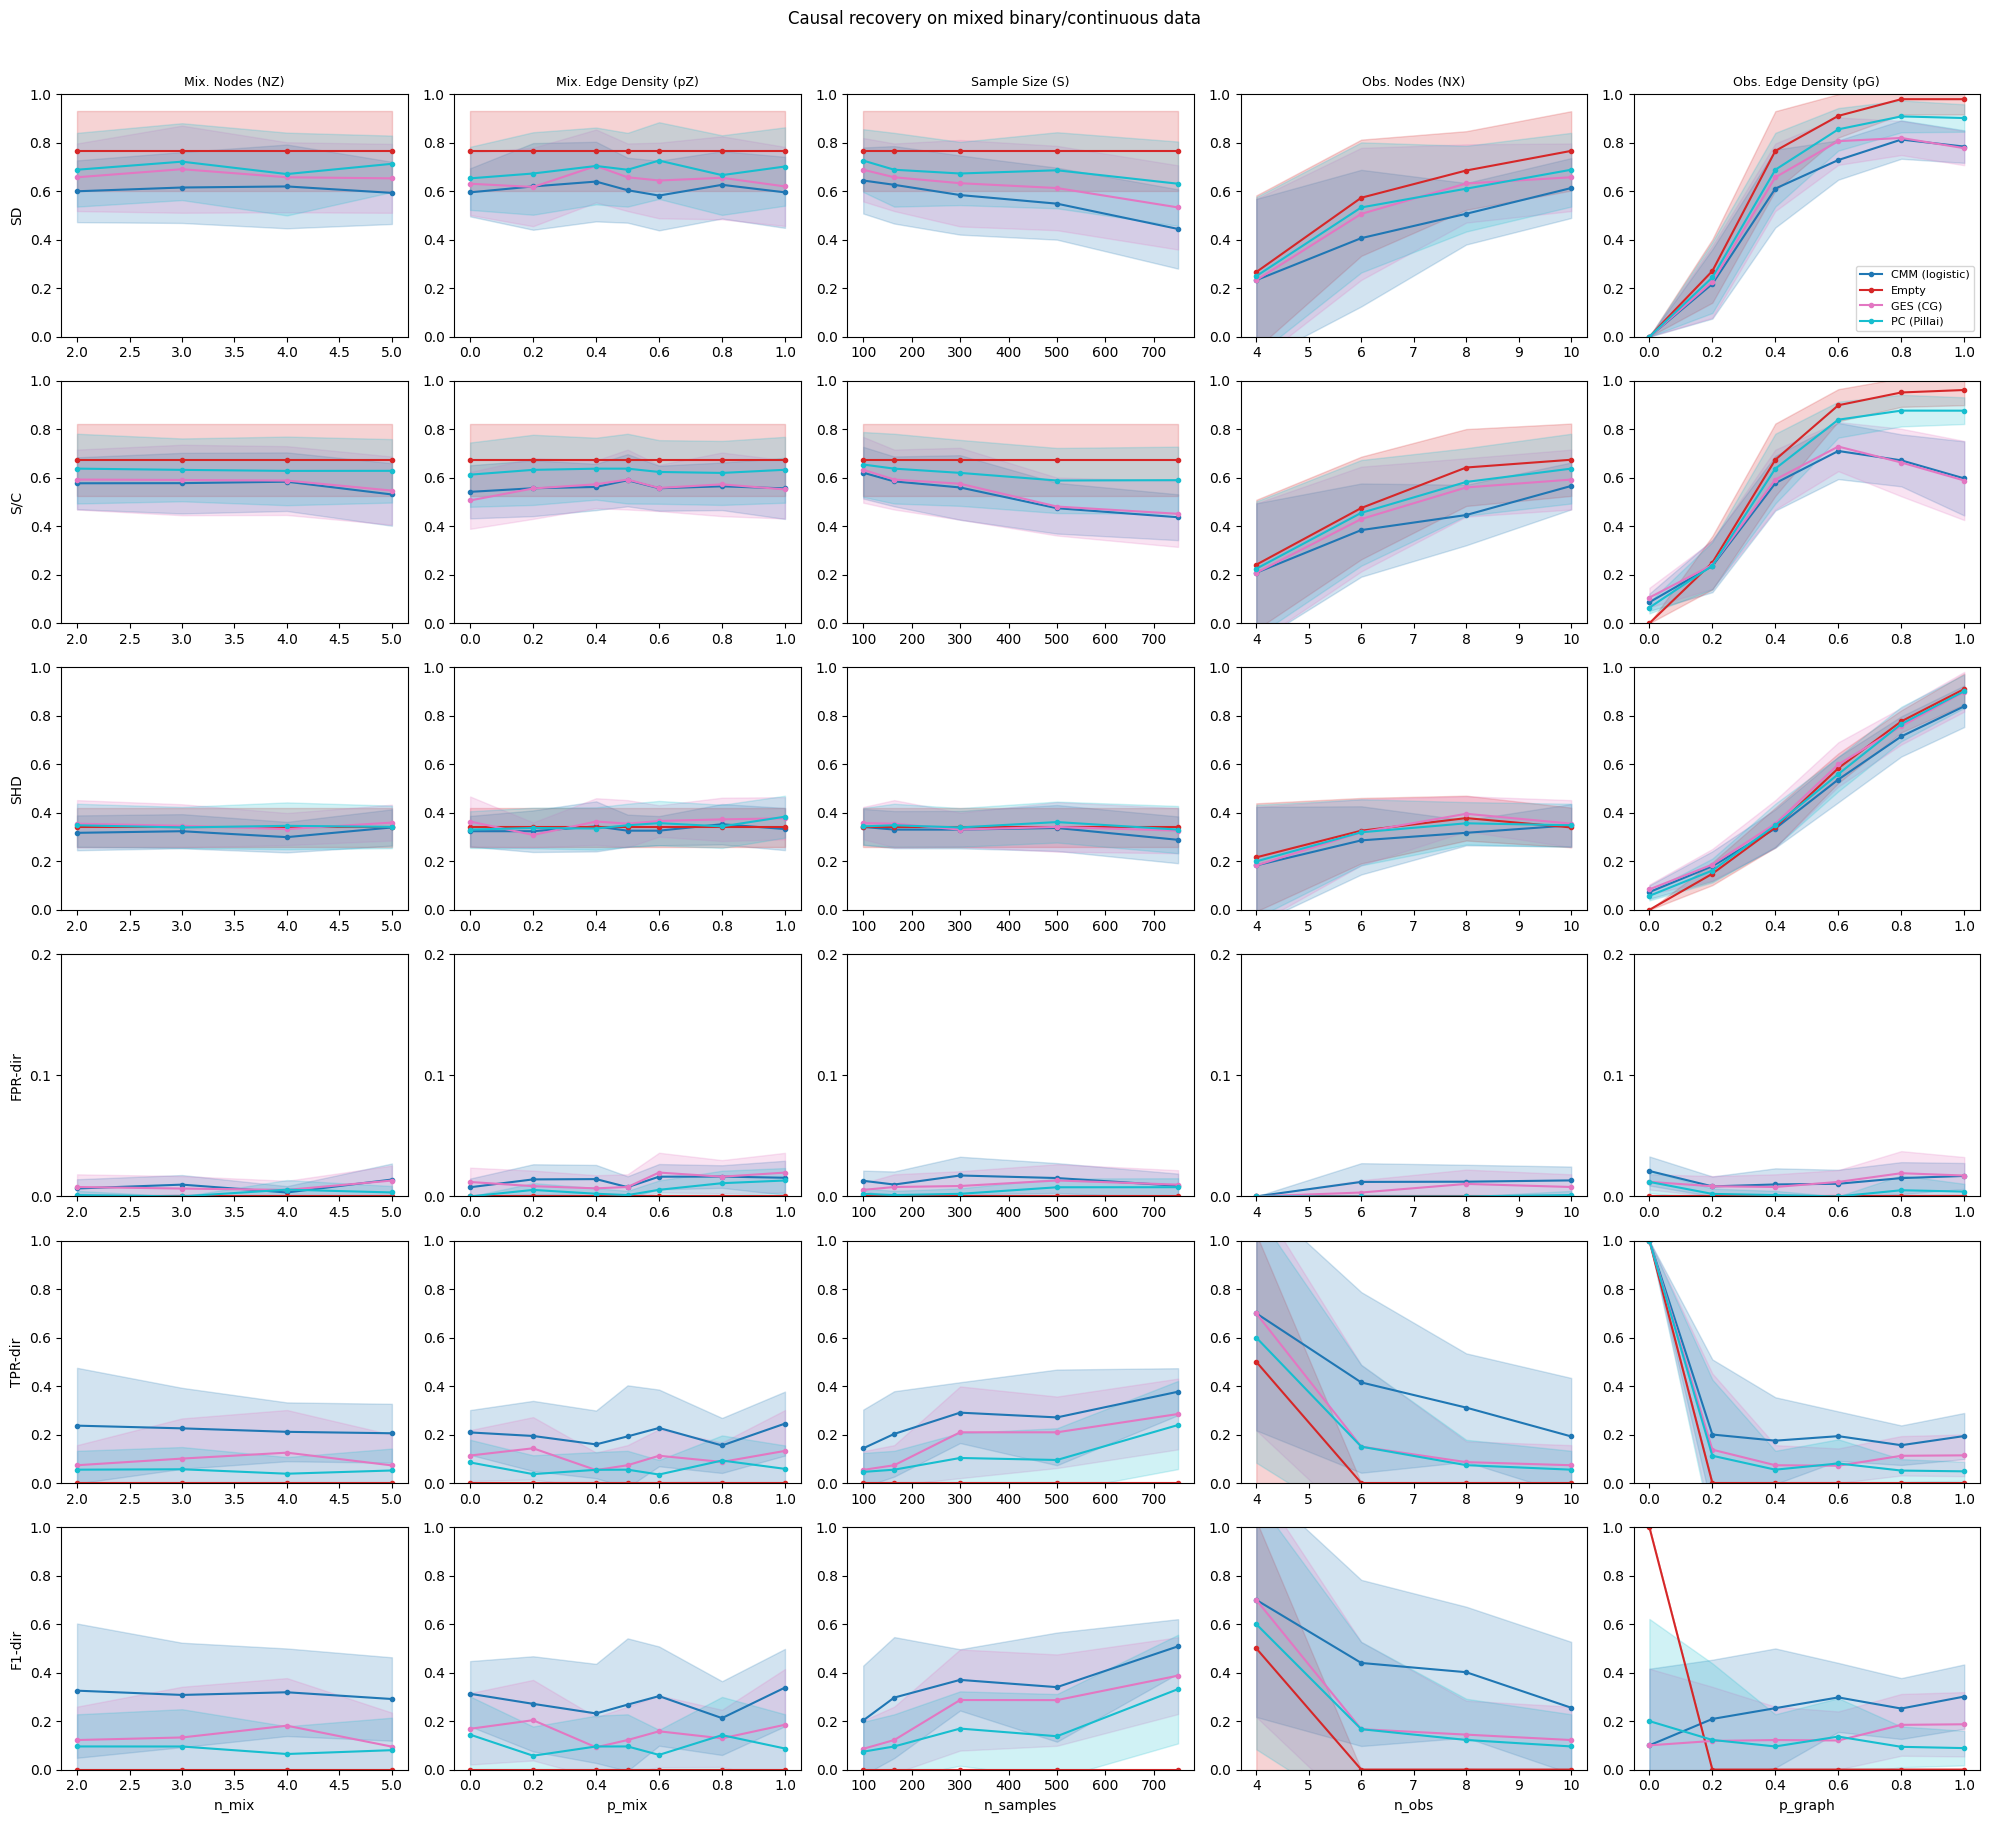

In [3]:
metric_labels = {
    'sd':  'SD',
    'sc':  'S/C',
    'shd': 'SHD',
    'fpr': 'FPR-dir',
    'tpr': 'TPR-dir',
    'f1':  'F1-dir',
}
plot_sweep(df_plot, metrics=list(metric_labels), metric_labels=metric_labels,
           param_labels=PARAM_LABELS, group_col='method', group_labels=method_labels,
           title='Causal recovery on mixed binary/continuous data')

## Edge-type breakdown

Splits F1 by edge class: mutation→mutation (`bin_bin`) vs mutation→MIC (`bin_cont`).

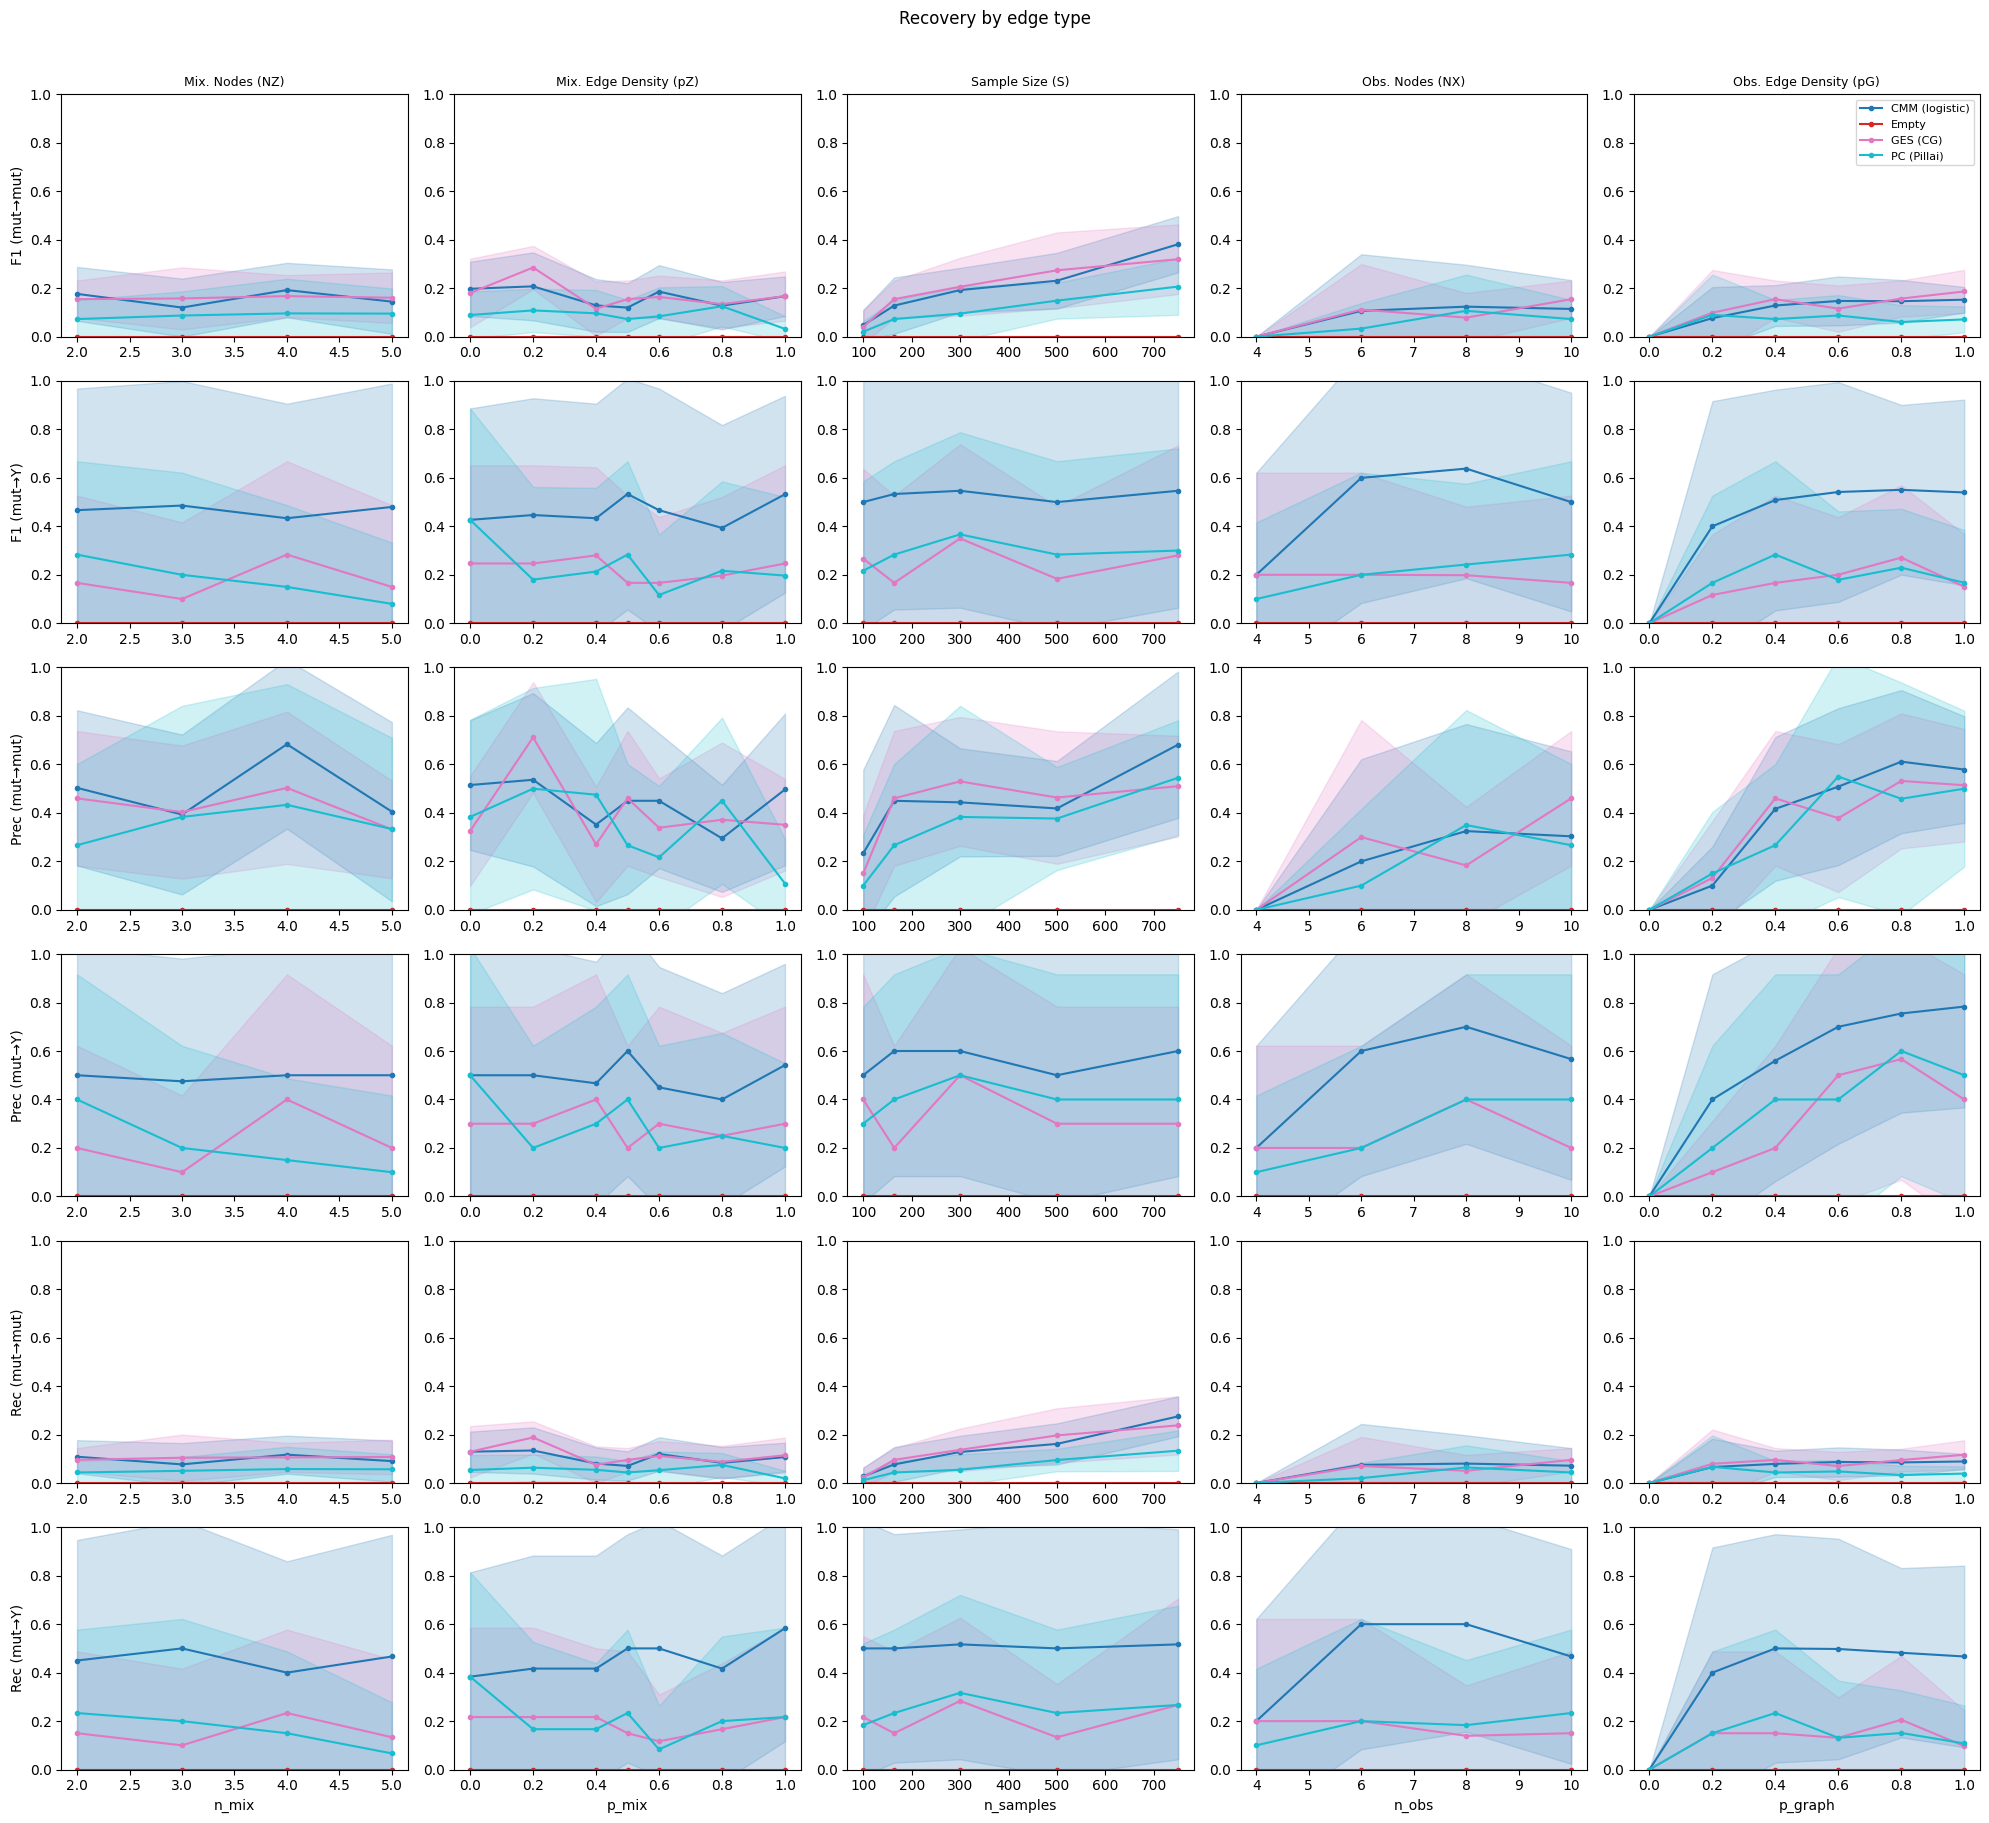

In [4]:
edge_metric_labels = {
    'f1_bin_bin':       'F1 (mut→mut)',
    'f1_bin_cont':      'F1 (mut→Y)',
    'precision_bin_bin':'Prec (mut→mut)',
    'precision_bin_cont':'Prec (mut→Y)',
    'recall_bin_bin':   'Rec (mut→mut)',
    'recall_bin_cont':  'Rec (mut→Y)',
}
plot_sweep(df_plot, metrics=list(edge_metric_labels), metric_labels=edge_metric_labels,
           param_labels=PARAM_LABELS, group_col='method', group_labels=method_labels,
           title='Recovery by edge type')

## Defaults-only summary table

Mean metrics at each method's default-config rows (n_obs=10, p_graph=0.4, p_mix=0.5, n_mix=2, n_samples=164).

In [5]:
from experiments.mixed_cmm.synthetic.config import DEFAULTS
param_to_default = {'n_mix': DEFAULTS['n_mix'], 'p_mix': DEFAULTS['p_mix'],
                    'n_samples': DEFAULTS['n_samples'], 'n_obs': DEFAULTS['n_obs'],
                    'p_graph': DEFAULTS['p_graph']}
mask = df_plot.apply(lambda r: r['value'] == param_to_default.get(r['param']), axis=1)
df_def = df_plot[mask]
summary = df_def.groupby('method')[['f1', 'tpr', 'fpr', 'shd', 'f1_bin_bin', 'f1_bin_cont']].mean().round(3)
summary.loc[methods_order]

,f1,tpr,fpr,shd,f1_bin_bin,f1_bin_cont
method,,,,,,
cmm_logistic,0.280,0.200,0.009,0.332,0.134,0.508
pc_pillai,0.095,0.055,0.001,0.349,0.073,0.283
ges_cg,0.122,0.073,0.008,0.356,0.155,0.167
empty,0.000,0.000,0.000,0.340,0.000,0.000
